In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_raw = pd.read_csv("D:\\ML&DL\\heart.csv")
data = data_raw.copy()

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
data.replace({"Age":0 , "RestingBP":0 , "Cholesterol":0 , "MaxHR":0 },np.nan , inplace=True)

In [5]:
data.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [6]:
data_categorical = data.select_dtypes("object")
data_numerical = data.select_dtypes(["float64" , "int64"]).iloc[:,:-1]
y = data.iloc[:,-1].values

In [7]:
data_numerical

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
0,40,140.0,289.0,0,172,0.0
1,49,160.0,180.0,0,156,1.0
2,37,130.0,283.0,0,98,0.0
3,48,138.0,214.0,0,108,1.5
4,54,150.0,195.0,0,122,0.0
...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2
914,68,144.0,193.0,1,141,3.4
915,57,130.0,131.0,0,115,1.2
916,57,130.0,236.0,0,174,0.0


In [8]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()

In [9]:
data_categorical = data_categorical.apply(label_enc.fit_transform)

In [10]:
data_categorical.head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,1,1,1,0,2
1,0,2,1,0,1
2,1,1,2,0,2
3,0,0,1,1,1
4,1,2,1,0,2


In [11]:
data_categorical.nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

In [12]:
from sklearn.preprocessing import OneHotEncoder
ohe_enc = OneHotEncoder()

In [13]:
data_categorical_bin = data_categorical[["Sex","ExerciseAngina"]]

In [14]:
data_ohe = ohe_enc.fit_transform(data_categorical[["ChestPainType", "RestingECG" , "ST_Slope"]].values).toarray()

In [15]:
data_ohe.shape

(918, 10)

In [16]:
data = np.concatenate([data_numerical.values , data_categorical_bin.values , data_ohe], axis = 1)

In [17]:
pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,40.0,140.0,289.0,0.0,172.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,110.0,264.0,0.0,132.0,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68.0,144.0,193.0,1.0,141.0,3.4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57.0,130.0,131.0,0.0,115.0,1.2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57.0,130.0,236.0,0.0,174.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [18]:
from sklearn.impute import KNNImputer

In [19]:
imputer = KNNImputer(n_neighbors=3)

In [20]:
data = imputer.fit_transform(data)

In [21]:

from sklearn.preprocessing import MinMaxScaler

In [22]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [23]:
X = data

# Decision Tree Classifier

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [25]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3 ,random_state=1234)

In [26]:
dtree  = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
dtree.score(X_train,y_train)

1.0

In [28]:
dtree.score(X_test , y_test)

0.8260869565217391

Observing overfit.

In [29]:
dtree  = DecisionTreeClassifier(max_depth=3)
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
dtree.score(X_train , y_train)

0.8489096573208723

In [31]:
dtree.score(X_test , y_test)

0.8695652173913043

Ploting the tree for visualizing the status.

In [32]:
from sklearn.tree import plot_tree

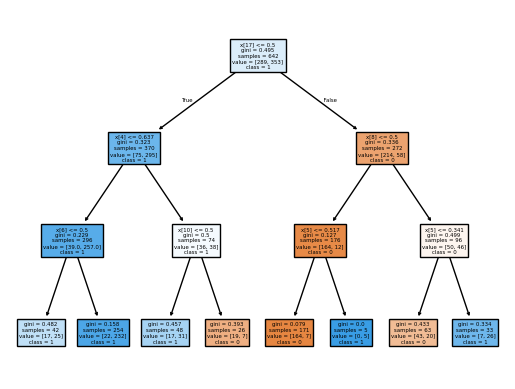

In [33]:
plot_tree(dtree , filled=True , class_names=["0" , "1"])
plt.show()

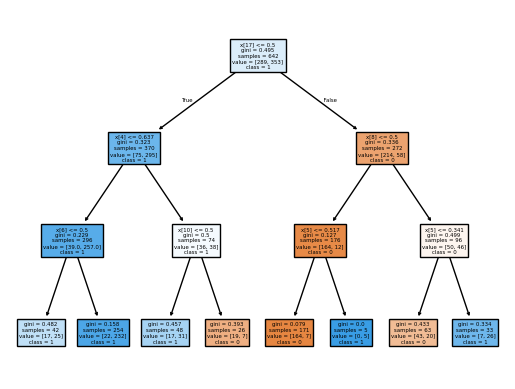

In [40]:
fig = plt.Figure(figsize=(45,30))
_ = plot_tree(dtree , filled=True , class_names=["0" , "1"])